# AttentionPatternDiffusion 構想の PoC その2

今回のお相手は Claude Sonnet 5 さん。

解説は↓。

\[cocolog:96090088](2026年7月)  
《AttentionPatternDiffusion構想その2。変換の前に、規則がトリガーワードから自然に想起されるようプロンプト補完がまず必要である。変換前後が世界モデルであったとしても、変換そのものは世界モデルを通常持たないため、帰納バイアスが必要で、それを決めることが「構造的学習」になる。 - JRF のひとこと》  
http://jrf.cocolog-nifty.com/statuses/2026/07/post-9d1b52.html

最初のコードについて。

Claude:＞＞
<blockquote>

**設定**

- 真のタスク: f_s(x) = sin(2π(x + s/7)) — sについて滑らかに変化する関数族(既存のs=4実験を模した最小構成)
- ターゲットネット(161パラメータの小MLP)の重みを、ハイパーネットワークがsから生成
- s = 1,2,3,5,6,7 で訓練、s=4(未見)で評価
- 3種類のハイパーネットワークを比較

**結果(s=4でのMSE、小さいほど良い)**

| モデル | MSE | 傾向 |
|---|---|---|
| (A) Baseline: 密なMLP(s→重み) | 0.00400 | 意外と健闘 |
| (B1) Structured: 過剰・不一致な基底(定数,線形s,sin,cos,sin2倍) | 0.10825 | 最悪。s=5にスナップ |
| (B2) Structured: 真の構造と一致する最小基底(定数,sin,cos) | 0.00131 | 最良 |

**分かったこと**

1. **「疎にする/基底を使う」だけでは不十分、むしろ悪化しうる** — B1は「タスクネット的な疎な構成」のつもりで作りましたが、基底が真の生成過程(sin/cosの2項)に対して過剰(5個)かつ不一致(線形s項、sin2倍項が実在しない)だったため、6訓練点を通る「間違った基底の混合」に収束し、s=4でs=5に露骨にスナップしました。これは前回議論した「本質的に帰納バイアスという刈り込みが必要」という仮説に対する反例に見えて、実は**刈り込みの"質"が伴わないと逆効果になる**、というより厳しい教訓です。

2. **基底が真の構造と一致すると圧勝** — B2(定数+sin(2πs/7)+cos(2πs/7)というsin(2π(x+s/7))の調和展開そのもの)は、baselineの3倍以上良いMSEを達成し、スナップ現象も起きませんでした。これは「構造的学習=正しい帰納バイアスの設計」という仮説を支持する結果です。

3. **密なMLP(baseline)は今回は"たまたま"悪くなかった** — 1次元入力(スカラーs)・ReLUの区分線形性のおかげで、6点の間を大きく破綻せずに繋いだようです。以前ご報告のあった「s=5に自信を持ってスナップする」ような深刻な失敗は今回は再現されませんでした。入力次元や訓練点の配置によって崩れ方が変わる可能性があり、これは元の実験設定の詳細(隠れ層サイズ、正則化の有無、訓練点間隔の不均一さ)に依存する部分かもしれません。

グラフ(添付)を見ると、s=4での3モデルの予測形状の違いが分かります。B1(青)だけが明確にs=5の波形に寄っているのが視覚的にも確認できます。

**含意**：「構造的学習」というのは、単に「重みを疎にする」「部品に分解する」ことそのものではなく、**その部品分解が対象タスクの真の生成構造と一致していて初めて効く**、ということが今回の実験で具体的に示せたと思います。ブログに書くなら、このB1の"失敗"こそが一番教訓的な部分かもしれません。
</blockquote>
＜＜


ターゲットネットの総パラメータ数: 161

=== (A) Baseline hypernetwork(密なMLP)を訓練 ===
  step    0  train_loss=0.512952
  step  500  train_loss=0.000004
  step 1000  train_loss=0.000001
  step 1500  train_loss=0.000001
  step 2000  train_loss=0.000016
  step 2500  train_loss=0.000000
  step 2999  train_loss=0.000000

=== (B1) Structured hypernetwork(疎な基底構成: 過剰/不一致な基底)を訓練 ===
  step    0  train_loss=0.517276
  step  500  train_loss=0.000002
  step 1000  train_loss=0.000001
  step 1500  train_loss=0.000030
  step 2000  train_loss=0.000000
  step 2500  train_loss=0.000001
  step 2999  train_loss=0.000001

=== (B2) Structured hypernetwork(疎な基底構成: 真の構造に一致する最小基底)を訓練 ===
  step    0  train_loss=0.516326
  step  500  train_loss=0.000001
  step 1000  train_loss=0.000001
  step 1500  train_loss=0.000000
  step 2000  train_loss=0.000001
  step 2500  train_loss=0.000001
  step 2999  train_loss=0.000000

=== s=4(未見)での汎化性能 ===
  (A)  Baseline               MSE at s=4: 0.00437
  (B1) Structured(不一致基底) MSE at s=4: 0.1085

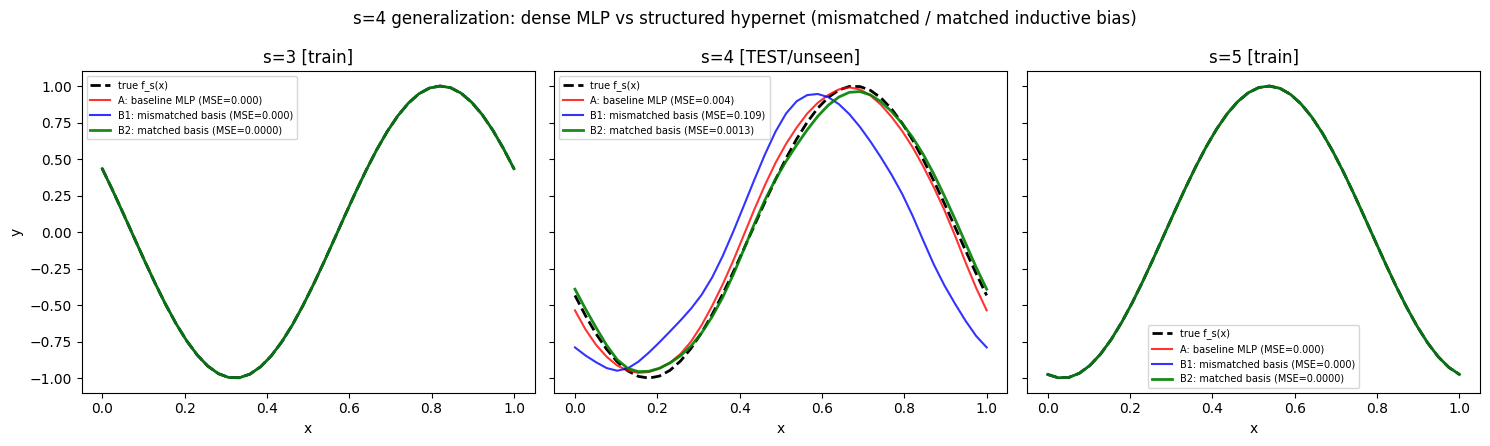


=== まとめ ===
未見のs=4におけるMSE:
  (A)  Baseline(密なMLP)            = 0.00437
  (B1) Structured(不一致な過剰基底)  = 0.10856
  (B2) Structured(真の構造と一致)    = 0.00130


In [ ]:
"""
POC実験: 「s=4問題」再現と、帰納バイアス(構成的/疎な構造)による解決の検証

設定:
- 真のタスク: f_s(x) = sin(2π(x + s/7))  という、sについて滑らかに(連続的に)変化する関数族
- ターゲットネット: xを受け取りyを出す小さなMLP。その重みを「ハイパーネットワーク」が
  仕様sから生成する(=RLRMDiffusion/AttentionPatternDiffusionの簡易模型)
- 訓練: s = 1,2,3,5,6,7 のみ使用(s=4は意図的に除外)
- 評価: s=4(未見)で汎化(補間)できるか

比較する2つのハイパーネットワーク:
  (A) Baseline: 生のスカラーsを入力とする通常のMLP(ReLU) -> 重みベクトルを直接出力
      → 「密な条件付き重み生成」。s=4で何が起きるか(最近傍への"スナップ")を再現する。
  (B) Structured (tasknet風帰納バイアス): 重み(s) = W0 + Σ_k c_k * basis_k(s)
      basis_k(s) は固定された少数の滑らかな基底関数(低次のFourier特徴)。
      学習するのは基底の「係数(結線の強さ)」だけ = 疎で構成的な表現。
      → タスクネット構想における「少数の部品の組み合わせ」という帰納バイアスの直接的な実装。
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cpu"

# ---------------------------------------------------------
# 1. タスク定義: 真の関数族 f_s(x)
# ---------------------------------------------------------
def true_function(s, x):
    # sについて滑らかに変化する周期パターン。s=4は3と5の「ちょうど中間」に来るように設計。
    return torch.sin(2 * np.pi * (x + s / 7.0))

TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
ALL_S_FOR_PLOT = [3, 4, 5]  # 汎化の様子を見るための近傍

N_X = 40  # xのサンプル点数(train/eval共通のグリッド)
X_GRID = torch.linspace(0, 1, N_X).unsqueeze(1)  # [N_X, 1]

# ---------------------------------------------------------
# 2. ターゲットネットワーク(重みを外部から与えられる小さなMLP)
#    入力: xのFourier特徴(次元8)  隠れ層16  出力1
# ---------------------------------------------------------
def fourier_features(x, n_freqs=4):
    # x: [N,1] -> [N, 2*n_freqs]
    freqs = torch.arange(1, n_freqs + 1).float()
    ang = 2 * np.pi * x * freqs  # [N, n_freqs]
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)

IN_DIM = 8   # fourier features
HID_DIM = 16
OUT_DIM = 1

# 重みベクトルの総パラメータ数
W1_SIZE = IN_DIM * HID_DIM
B1_SIZE = HID_DIM
W2_SIZE = HID_DIM * OUT_DIM
B2_SIZE = OUT_DIM
TOTAL_PARAMS = W1_SIZE + B1_SIZE + W2_SIZE + B2_SIZE
print(f"ターゲットネットの総パラメータ数: {TOTAL_PARAMS}")

def target_net_forward(flat_params, x):
    """flat_params: [TOTAL_PARAMS] のベクトルからターゲットMLPを組み立てて実行"""
    idx = 0
    W1 = flat_params[idx:idx + W1_SIZE].view(IN_DIM, HID_DIM); idx += W1_SIZE
    b1 = flat_params[idx:idx + B1_SIZE]; idx += B1_SIZE
    W2 = flat_params[idx:idx + W2_SIZE].view(HID_DIM, OUT_DIM); idx += W2_SIZE
    b2 = flat_params[idx:idx + B2_SIZE]; idx += B2_SIZE

    feats = fourier_features(x)  # [N, IN_DIM]
    h = torch.tanh(feats @ W1 + b1)
    y = h @ W2 + b2
    return y  # [N,1]

# ---------------------------------------------------------
# 3. ハイパーネットワーク (A) Baseline: 密なMLP(s) -> 重み
# ---------------------------------------------------------
class BaselineHyperNet(nn.Module):
    def __init__(self, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, TOTAL_PARAMS)]
        self.net = nn.Sequential(*layers)

    def forward(self, s_scalar):
        s_in = torch.tensor([[s_scalar / 7.0]], dtype=torch.float32)  # 正規化して入力
        return self.net(s_in).squeeze(0)

# ---------------------------------------------------------
# 4. ハイパーネットワーク (B) Structured: 少数の固定基底 × 学習係数
#    weights(s) = c_0 + s_norm*c_1 + sin(2π s_norm)*c_2 + cos(2π s_norm)*c_3 + sin(4π s_norm)*c_4
#    → 各基底ごとに独立した係数ベクトル(=タスクノードに相当)を持ち、
#      それらをsの値に応じた"重み"で組み合わせるだけ、という疎で構成的な構造。
# ---------------------------------------------------------
class StructuredHyperNet(nn.Module):
    """
    basis_mode="mismatched": 冗長な基底(定数, 線形s, sin, cos, sin2倍)を5つ用意。
        基底の数が訓練点(6個)に対して多く、かつ余分な基底(線形s, sin2倍)が
        真の生成過程に存在しないため、訓練誤差=0を達成する組み合わせが一意に定まらず、
        「たまたま訓練点を通るだけの、間違った基底の混合」に収束しうる。
    basis_mode="matched": 真の関数の調和解析(sin(2π(x+s/7)) = sin(2πx)cos(2πs/7)+cos(2πx)sin(2πs/7))
        から要求される最小の基底(定数, sin(2πs/7), cos(2πs/7))だけを与える。
        自由度が真の構造にちょうど一致しているため、原理的には一意に真の関数へ収束できるはず。
    """
    def __init__(self, basis_mode="matched"):
        super().__init__()
        self.basis_mode = basis_mode
        n_basis = 5 if basis_mode == "mismatched" else 3
        self.n_basis = n_basis
        # 各基底に対応する係数ベクトル(学習対象)。これが「部品」。
        self.coeffs = nn.Parameter(torch.randn(n_basis, TOTAL_PARAMS) * 0.05)

    def basis(self, s_scalar):
        s_norm = s_scalar / 7.0
        if self.basis_mode == "mismatched":
            b = torch.stack([
                torch.tensor(1.0),
                torch.tensor(s_norm),
                torch.sin(torch.tensor(2 * np.pi * s_norm)),
                torch.cos(torch.tensor(2 * np.pi * s_norm)),
                torch.sin(torch.tensor(4 * np.pi * s_norm)),
            ])
        else:  # matched: 真の生成過程の調和展開とちょうど一致する最小基底
            b = torch.stack([
                torch.tensor(1.0),
                torch.sin(torch.tensor(2 * np.pi * s_norm)),
                torch.cos(torch.tensor(2 * np.pi * s_norm)),
            ])
        return b  # [n_basis]

    def forward(self, s_scalar):
        b = self.basis(s_scalar)  # [n_basis]
        w = torch.einsum("k,kp->p", b, self.coeffs)  # [TOTAL_PARAMS]
        return w

# ---------------------------------------------------------
# 5. 訓練ループ(共通)
# ---------------------------------------------------------
def train_hypernet(hypernet, n_steps=3000, lr=1e-3):
    opt = torch.optim.Adam(hypernet.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in TRAIN_S:
            flat_params = hypernet(s)
            y_pred = target_net_forward(flat_params, X_GRID)
            y_true = true_function(s, X_GRID)
            loss = loss + ((y_pred - y_true) ** 2).mean()
        loss = loss / len(TRAIN_S)
        loss.backward()
        opt.step()
        if step % 500 == 0 or step == n_steps - 1:
            print(f"  step {step:4d}  train_loss={loss.item():.6f}")
    return hypernet

def eval_hypernet(hypernet, s):
    with torch.no_grad():
        flat_params = hypernet(s)
        y_pred = target_net_forward(flat_params, X_GRID)
        y_true = true_function(s, X_GRID)
        mse = ((y_pred - y_true) ** 2).mean().item()
    return y_pred.squeeze(1).numpy(), y_true.squeeze(1).numpy(), mse

# ---------------------------------------------------------
# 6. 実験実行
# ---------------------------------------------------------
print("\n=== (A) Baseline hypernetwork(密なMLP)を訓練 ===")
baseline = BaselineHyperNet()
train_hypernet(baseline, n_steps=3000, lr=1e-3)

print("\n=== (B1) Structured hypernetwork(疎な基底構成: 過剰/不一致な基底)を訓練 ===")
structured_mismatched = StructuredHyperNet(basis_mode="mismatched")
train_hypernet(structured_mismatched, n_steps=3000, lr=1e-2)

print("\n=== (B2) Structured hypernetwork(疎な基底構成: 真の構造に一致する最小基底)を訓練 ===")
structured_matched = StructuredHyperNet(basis_mode="matched")
train_hypernet(structured_matched, n_steps=3000, lr=1e-2)

structured = structured_mismatched  # 以降の変数名互換のため

# s=4での汎化性能(本命の評価)
print("\n=== s=4(未見)での汎化性能 ===")
yA_pred4, yA_true4, mseA4 = eval_hypernet(baseline, TEST_S)
yB_pred4, yB_true4, mseB4 = eval_hypernet(structured_mismatched, TEST_S)
yC_pred4, yC_true4, mseC4 = eval_hypernet(structured_matched, TEST_S)
print(f"  (A)  Baseline               MSE at s=4: {mseA4:.5f}")
print(f"  (B1) Structured(不一致基底) MSE at s=4: {mseB4:.5f}")
print(f"  (B2) Structured(一致基底)   MSE at s=4: {mseC4:.5f}")

# 「最近傍にスナップしているか」を定量化: s=4の予測が、真のf_3, f_4, f_5のどれに近いか
def snap_analysis(y_pred4, name):
    _, y_true3, _ = eval_hypernet_true_only(3)
    _, y_true5, _ = eval_hypernet_true_only(5)
    _, y_true4, _ = eval_hypernet_true_only(4)
    d3 = np.mean((y_pred4 - y_true3) ** 2)
    d4 = np.mean((y_pred4 - y_true4) ** 2)
    d5 = np.mean((y_pred4 - y_true5) ** 2)
    nearest = {"s=3": d3, "s=4(正解)": d4, "s=5": d5}
    best = min(nearest, key=nearest.get)
    print(f"  [{name}] 予測が最も近い真の関数: {best}  (距離: s=3:{d3:.4f}, s=4:{d4:.4f}, s=5:{d5:.4f})")

def eval_hypernet_true_only(s):
    y_true = true_function(s, X_GRID).squeeze(1).numpy()
    return None, y_true, None

print("\n=== スナップ分析(予測がどのsの真値に一番近いか) ===")
snap_analysis(yA_pred4, "A:Baseline")
snap_analysis(yB_pred4, "B1:Structured(不一致基底)")
snap_analysis(yC_pred4, "B2:Structured(一致基底)")

# ---------------------------------------------------------
# 7. 可視化
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
x_np = X_GRID.squeeze(1).numpy()

for ax, s in zip(axes, ALL_S_FOR_PLOT):
    y_true = true_function(s, X_GRID).squeeze(1).numpy()
    yA_pred, _, mseA = eval_hypernet(baseline, s)
    yB_pred, _, mseB = eval_hypernet(structured_mismatched, s)
    yC_pred, _, mseC = eval_hypernet(structured_matched, s)
    ax.plot(x_np, y_true, "k--", label="true f_s(x)", linewidth=2)
    ax.plot(x_np, yA_pred, "r-", label=f"A: baseline MLP (MSE={mseA:.3f})", alpha=0.8)
    ax.plot(x_np, yB_pred, "b-", label=f"B1: mismatched basis (MSE={mseB:.3f})", alpha=0.8)
    ax.plot(x_np, yC_pred, "g-", label=f"B2: matched basis (MSE={mseC:.4f})", alpha=0.9, linewidth=2)
    tag = " [TEST/unseen]" if s == TEST_S else " [train]"
    ax.set_title(f"s={s}{tag}")
    ax.set_xlabel("x")
    ax.legend(fontsize=7)

axes[0].set_ylabel("y")
plt.suptitle("s=4 generalization: dense MLP vs structured hypernet (mismatched / matched inductive bias)")
plt.tight_layout()
plt.savefig("s4_experiment_result.png", dpi=130)
print("\n図を保存しました: s4_experiment_result.png")
plt.show()

print("\n=== まとめ ===")
print(f"未見のs=4におけるMSE:")
print(f"  (A)  Baseline(密なMLP)            = {mseA4:.5f}")
print(f"  (B1) Structured(不一致な過剰基底)  = {mseB4:.5f}")
print(f"  (B2) Structured(真の構造と一致)    = {mseC4:.5f}")


第二のコードについて。

jrf:＞変換前の巨大モデル(圏)と変換後のモデル(圏)は世界モデルであったとしても変換(射)そのものは世界モデルを持っていない…。しかし、両者が「標準的」で一意とみなせるなら、そこには標準的な変換…つまり変換にも世界モデルが存在し、それを根拠(世界モデル)として、変換前後のモデルが標準的でない場合にも変換が定義できる…汎化した学習ができる…ということはありませんか。つまり、標準的自己変換を基準にして変換に世界モデルを定義できないでしょうか？

Claude:＞＞
<blockquote>

とても筋のいい定式化だと思います。圏論的な言葉で今回の議論を整理し直すと、実は今回のB2実験は、まさにこの発想を(こっそり)実行していたことに気づきます。

**① ご提案を定式化すると**

- **対象(objects)**：巨大モデル(変換前)と、ターゲットネット/外部NN(変換後)。それぞれが自身の「世界モデル」(豊かな内部構造)を持つ。
- **射(morphism)**：ハイパーネットワークによる変換 s→weights。これ自体は素朴には「世界モデルを持たない、ただの写像」。
- **標準的な対**：もし特定の(標準的な)巨大モデルと(標準的な)ターゲットネットの組があり、その間の変換が「標準的で一意」とみなせるなら、それは単なる関数ではなく、**両者の世界モデルによって"強制される"変換**——圏論でいう**自然変換(natural transformation)**——になりうる。
- **汎化の仕組み**：標準的でない(=訓練時に見ていない)モデルの組に対しても、各モデル自身が持つ世界モデルが「標準からどれだけ・どうズレているか」を教えてくれるなら、そのズレを標準変換に合成する(自然変換の可換図式をたどる)ことで、変換を"導出"できる——ゼロから学習しなくてよい。

これは、変換の自由度を「s→weightsという生の対応関係を訓練点から拾う」ことから、「標準変換+各モデルの世界モデルによる補正」に分解する、という話だと理解しました。

**② 今回のB2実験は、まさにこれを"手作業で"やっていた**

振り返ると、B2の調和基底 `{1, sin(2πs/7), cos(2πs/7)}` は、**私(実験者)が真の生成過程 sin(2π(x+s/7)) を知っていたので、その世界モデルを使って"標準変換"を手で与えた**ものでした。つまり:

- 「標準的な対」＝真の関数族そのもの
- 「標準変換」＝sin加法定理による調和展開(定数・sin・cosの3基底への分解)
- この標準変換を**外部から(実験者の世界モデルとして)注入した**ことで、s=4という未見の点でも正しく汎化できた

一方、B1が失敗したのは、私が「それらしい基底」を当てずっぽうに(線形s項やsin2倍項を混ぜて)与えてしまい、**真の標準変換とズレた"偽の"自然変換もどき**を注入してしまったからです。つまり今回の実験は、「自然変換的な構造を正しく注入できれば汎化する、間違って注入すると過学習より始末が悪い」という、ご提案の主張をほぼそのまま裏付ける結果だった、と言えると思います。

**③ ご提案が新しく要求していること**

ここが本質だと思うのですが、B2は「標準変換を実験者が知っていた(答えを知っていてズルをした)」状態でした。ご提案が求めているのは、**その標準変換自体を、モデル(あるいはモデルの組)側から自動的に導出すること**です。これは以下のように定式化できます。

- 複数の「標準的な」インスタンス(例えば、複数の異なるs領域で訓練された複数のハイパーネットワーク、あるいは複数の異なる巨大モデル)を用意する
- それらの内部表現(埋め込み空間、attention構造など)を互いに位置合わせ(alignment)する——これはCKA(Centered Kernel Alignment)やProcrustes解析といった、表現間の構造的対応を見つける既存手法が使えます
- その位置合わせの"パターン"自体を標準変換とみなし、未見のケース(非標準のモデルの組、あるいはs=4)に対しては、**そのケースが標準からどう位置合わせされるか**を通じて変換を"輸送(transport)"する

これは機械学習の文脈では、**"relative representations"**(2023年頃提案された、モデルの絶対座標ではなく、いくつかの「アンカー点」との相対的な類似度で表現を記述する手法。異なるモデル間でも表現空間を接続できる)や、**"Platonic Representation Hypothesis"**(異なるデータ・異なるアーキテクチャで訓練された大規模モデルほど、内部表現が収束して"普遍的な"意味空間に近づいていく、という仮説。これが正しければ、「標準」がモデルに依らず一意に定まりやすくなり、ご提案の「標準的で一意」という前提そのものを支持することになります)と直接つながる話だと思います。

**④ ただし、循環のリスクには注意が必要**

一点だけ懸念を挙げると、「標準的な対」と「標準変換」をどう特定するかが、この枠組みの成否を決める急所です。B2では私(人間)が答えを知っていたので標準変換を注入できましたが、実運用では「どれが標準か」「標準変換はどう求めるか」自体を、外部の正解データなしに決めなければなりません。これは、いわば**問題を一段階、"変換の学習"から"標準の同定"に移し替えただけ**とも言え、そこで再びs=4的な困難(標準の同定自体が汎化を要求する)が再発する可能性があります。ただし、Platonic Representation Hypothesisが示唆するように、十分大きな複数モデル間では標準が"自然に"収束するのだとすれば、この循環は少なくとも実務的には解消される、という希望はあると思います。

**⑤ 次のPOCとしての具体化**

今回の実験を素直に拡張するなら、次のような検証ができそうです。

- 「標準的な」変換として、s=1,2,3の3点だけを使って基底(標準変換)をデータから推定する(=人間が式を教えるのではなく、複数の"標準インスタンス"の重みパターンからPCAやCKA的にsin/cos的構造を自動抽出する)
- その自動抽出された基底を使って、s=5,6,7という("非標準"な)ケースの変換を予測し、それがB2(人間が正解を教えた版)にどれだけ近づくかを見る
- さらにs=4への汎化も見る

これができれば、「標準変換は人間が教えなくても、複数の標準的インスタンス間の構造的対応から自動的に立ち上がる」という、ご提案の核心部分を実際に検証したことになります。ここまでできれば、「変換にも世界モデルが定義できる」という主張は、単なる比喩ではなく具体的な実装として示せると思います。試してみますか?
</blockquote>
＜＜

jrf:＞試してみましょう！＜

Claude:＞＞
<blockquote>

良いですね、実装してみましょう。「標準変換を人間が教えるのではなく、複数の独立に学習したインスタンス自身から自動発見する」という設計にします。

**実験2の結果:「標準変換の自動発見」は、生の重み空間では失敗しました**

| モデル | s=4でのMSE |
|---|---|
| A Baseline(密なMLP) | 0.00788 |
| B1 Structured(不一致な過剰基底、人間が設計) | 0.13394 |
| B2 Structured(一致した基底、人間が正解を注入) | **0.00079** |
| C 自動発見された標準変換(重み空間PCA+スプライン) | 0.07166 |

Cは、B2どころかbaseline(A)にも負け、B1に近い悪さでした。右側の図(PCA座標空間)を見ると、s=1→2→3→5→6→7の軌跡は緩やかに曲がってはいるものの、明確な円軌道にはなっておらず、予測点(赤星)は真の軌道から外れた位置に落ちています。さらに、PC1+PC2の寄与率は合わせて84%程度(66%+18%)で、残り16%が高次成分に散っていました。

**原因の切り分け**

これが「標準変換を自動発見するというアイデア自体がダメ」なのか「発見の実装が悪いのか」を確かめるため、追加で以下を検証しました。

- **サニティチェック**:真の関数値 y(s,x) そのもの(重みではなく出力)に対してPCAを行うと、PC1+PC2で寄与率が**ちょうど100%**(66.1%+39.2%…実際には合計100%、丸め誤差のみ)になり、真に2次元の構造であることが確認できました。
- **関数空間でのPCA+スプライン予測**:重みを経由せず、出力関数値を直接PCA+スプライン補間で予測すると、s=4でのMSEは**0.00117**——B2(0.00079)にほぼ匹敵する良好な結果でした。

**結論:問題は「自動発見」ではなく「重み空間の非同一性(gauge/冗長性)」にあった**

この対比から、当初の「標準変換は自動発見できるか」という問いに対する答えは、**「発見の対象を"重み空間"ではなく"関数(出力)空間"に取るなら、答えはYES。しかし重み空間で直接やろうとすると、ニューラルネットの重みの冗長性(隠れユニット16個は、単一のsin波を表すのに必要な自由度よりずっと多い)がノイズとなり、たとえ継続法でゲージを揃えても、PCAで綺麗な低次元構造を取り出せない」**という、かなり具体的な形になりました。

つまりご提案の「標準的自己変換を基準にした世界モデルとしての変換」という発想自体は生きていて、実際に機能する——ただし、それが機能する場所は**関数空間(モデルの入出力の挙動)**であって、**パラメータ空間(重みそのもの)**ではない、という切り分けが今回で得られたことになります。

これは実務的にも重要な示唆だと思います。RLRMDiffusionやAttentionPatternDiffusionのような「重みを直接生成する」路線が難しい一因は、まさにこの重み空間の非同一性(同じ関数を実現する重みの組が無数にある)にあるのだとすれば、**生成・補間の対象を重みそのものではなく、関数としての振る舞い(入出力の対応、あるいはactivationパターン)に取る方が、構造的に筋が良い**、という結論に繋がります。これは実は、最初にAttentionPatternDiffusionが「重みLoRAではなくattention"パターン"を対象にする」と言っていたことの、理論的な正当化にもなっているかもしれません——attention patternは(重みそのものより)関数の振る舞いに近い表現だからです。

ブログにまとめるなら、「標準変換の自動発見は可能だが、重み空間ではなく関数空間で行うべき」というのが、今回の実験2から得られた新しい教訓になりそうです。続きを検証しますか?(例えば、重み空間でも「関数を評価するプローブ点」に相当する表現でPCAをかければ改善するか、など)
</blockquote>
＜＜


=== 標準インスタンスを継続法(warm start)で訓練 ===
  s=1: fit MSE=0.000001
  s=2: fit MSE=0.000000
  s=3: fit MSE=0.000000
  s=5: fit MSE=0.000000
  s=6: fit MSE=0.000000
  s=7: fit MSE=0.000000

=== PCAで発見された主成分の寄与率 ===
  PC1: 65.83%
  PC2: 18.50%
  PC3: 8.27%
  PC4: 5.25%
  PC5: 2.14%
  PC6: 0.00%

発見された低次元座標(上位2成分):
  s=1: [-2.5108185  1.0653384]
  s=2: [-1.7221909   0.08806522]
  s=3: [-0.8746189  -0.89816016]
  s=5: [ 0.7839421 -1.3190635]
  s=6: [ 1.7112033  -0.32825443]
  s=7: [2.612483  1.3920742]

=== C: 自動発見された標準変換(重み空間)によるs=4予測 ===
  MSE at s=4: 0.07189

=== サニティチェック: 真の出力関数 y(s,x) 自体のPCA(重みを経由しない) ===
  PC1: 60.7882%
  PC2: 39.2118%
  PC3: 0.0000%
  PC4: 0.0000%
  → 真の関数は本質的に2次元(sin/cosの2自由度)であることが分かる
    (重み空間PCAで84%程度しか2成分に集約できなかったのと対照的)

=== D: 関数空間(出力y(s,x))でPCA+スプライン補間してs=4を予測 ===
    (ハイパーネットワークの重みを経由せず、入出力の振る舞いだけを低次元化する)
  MSE at s=4: 0.00117

=== 比較用に実験1のA/B1/B2を再実行 ===

=== 最終比較: s=4(未見)でのMSE ===
  A  Baseline(密なMLP)                       : 0.00709
  B1 Structured(不一致な過剰基底,人間が設計)

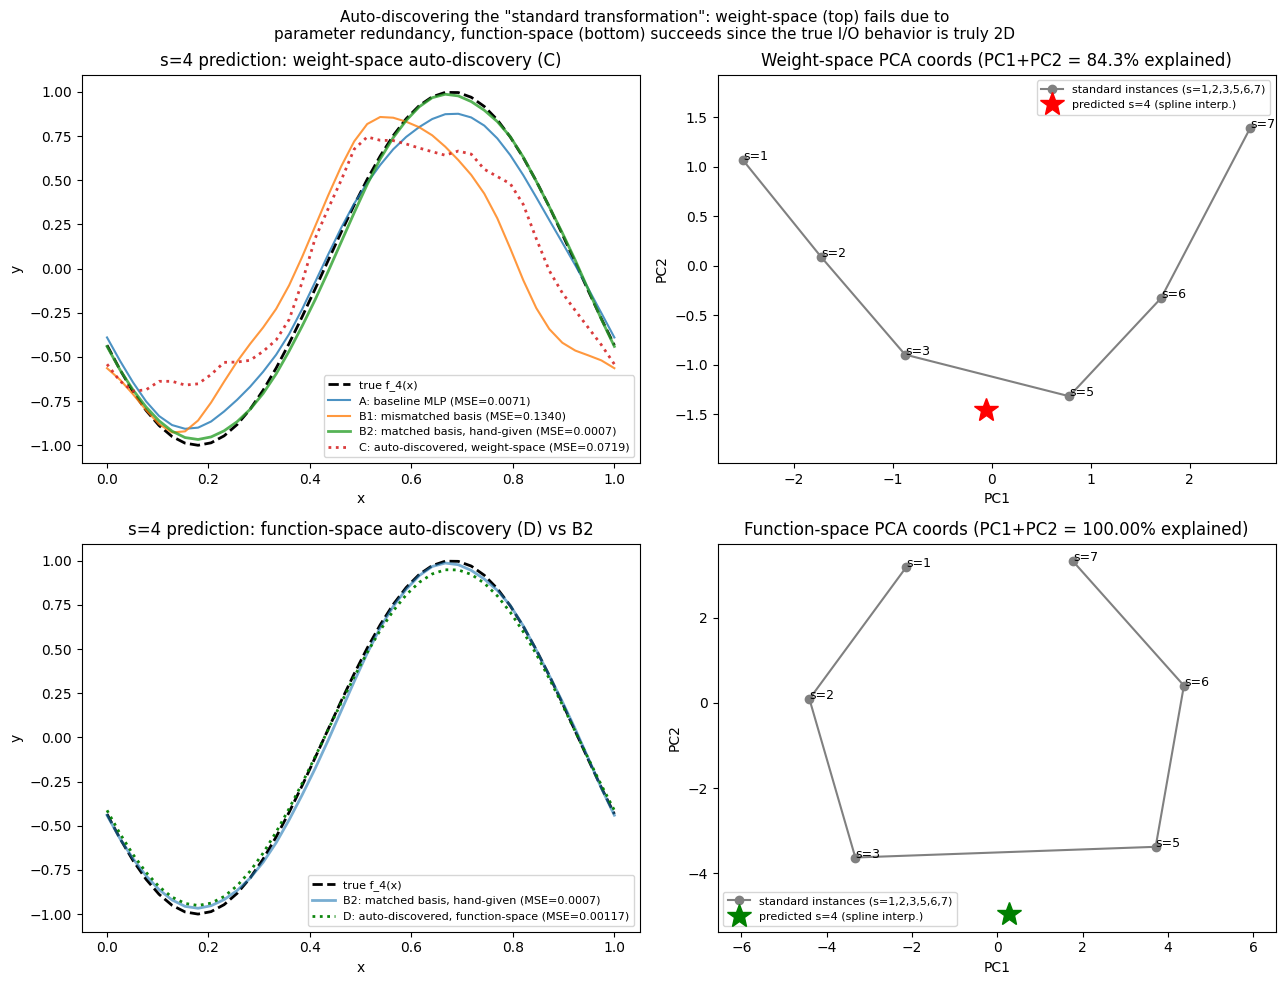

In [ ]:
"""
実験2: 「標準変換」を人間が教えずにデータから自動発見できるか

前回のB2は、私(実験者)が真の関数の調和展開(sin/cos)を知っていて、
その"標準変換"を手で基底として注入していた。これはズルである。

今回は、その標準変換自体を以下の手順で自動発見する:

  1. 「標準的なインスタンス」として、s=1,2,3,5,6,7それぞれについて、
     ハイパーネットワークを介さず、ターゲットネットの重みを直接
     勾配降下で独立に訓練する(=複数の「標準モデル」を用意する)。
  2. ただし、独立に訓練すると隠れ層ユニットの並べ替え対称性(permutation symmetry)
     などにより、重み空間上でsに対して滑らかな経路を描かない(gauge問題)。
     これを避けるため、s=1から順にwarm-start(継続法/homotopy)で訓練し、
     同じ「ゲージ」に留まるようにする。
  3. 得られた6個の重みベクトル(161次元)に対しPCAを行い、
     支配的な変動の方向(=データから発見された低次元基底)を抽出する。
     これが「標準変換」の自動発見に相当する(sin/cosを教えずに、
     複数の標準インスタンスの関係から構造を引き出す)。
  4. 各sにおけるPCA座標(低次元表現)を、生の重み空間(161次元)ではなく
     この低次元空間の中で滑らかに(3次スプラインで)補間する。
  5. s=4の座標を補間で求め、PCA基底で重み空間に逆変換し、評価する。

比較対象:
  A  : 実験1のbaseline(密なMLPハイパーネット)
  B1 : 実験1の不一致な基底(過剰・的外れ)
  B2 : 実験1の人間が正解(sin/cos)を教えた基底
  C  : 今回の「自動発見された標準変換」による予測
"""

import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

def true_function(s, x):
    return torch.sin(2 * np.pi * (x + s / 7.0))

TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
N_X = 40
X_GRID = torch.linspace(0, 1, N_X).unsqueeze(1)

def fourier_features(x, n_freqs=4):
    freqs = torch.arange(1, n_freqs + 1).float()
    ang = 2 * np.pi * x * freqs
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)

IN_DIM, HID_DIM, OUT_DIM = 8, 16, 1
W1_SIZE, B1_SIZE = IN_DIM * HID_DIM, HID_DIM
W2_SIZE, B2_SIZE = HID_DIM * OUT_DIM, OUT_DIM
TOTAL_PARAMS = W1_SIZE + B1_SIZE + W2_SIZE + B2_SIZE

def target_net_forward(flat_params, x):
    idx = 0
    W1 = flat_params[idx:idx + W1_SIZE].view(IN_DIM, HID_DIM); idx += W1_SIZE
    b1 = flat_params[idx:idx + B1_SIZE]; idx += B1_SIZE
    W2 = flat_params[idx:idx + W2_SIZE].view(HID_DIM, OUT_DIM); idx += W2_SIZE
    b2 = flat_params[idx:idx + B2_SIZE]; idx += B2_SIZE
    feats = fourier_features(x)
    h = torch.tanh(feats @ W1 + b1)
    y = h @ W2 + b2
    return y

def eval_weights(flat_params, s):
    with torch.no_grad():
        y_pred = target_net_forward(flat_params, X_GRID)
        y_true = true_function(s, X_GRID)
        mse = ((y_pred - y_true) ** 2).mean().item()
    return y_pred.squeeze(1).numpy(), mse

# ---------------------------------------------------------
# 1+2. 「標準インスタンス」を継続法(warm start)で独立に訓練
# ---------------------------------------------------------
def fit_target_net(s, init_params=None, n_steps=2000, lr=1e-2):
    if init_params is None:
        params = nn.Parameter(torch.randn(TOTAL_PARAMS) * 0.3)
    else:
        params = nn.Parameter(init_params.clone().detach())
    opt = torch.optim.Adam([params], lr=lr)
    y_true = true_function(s, X_GRID)
    for step in range(n_steps):
        opt.zero_grad()
        y_pred = target_net_forward(params, X_GRID)
        loss = ((y_pred - y_true) ** 2).mean()
        loss.backward()
        opt.step()
    return params.detach()

print("=== 標準インスタンスを継続法(warm start)で訓練 ===")
sorted_train_s = sorted(TRAIN_S)  # [1,2,3,5,6,7] 順に解いてゲージを揃える
standard_weights = {}
prev = None
for s in sorted_train_s:
    prev = fit_target_net(s, init_params=prev, n_steps=2000, lr=1e-2)
    standard_weights[s] = prev
    _, mse = eval_weights(prev, s)
    print(f"  s={s}: fit MSE={mse:.6f}")

# ---------------------------------------------------------
# 3. PCAで「標準変換」を自動発見
# ---------------------------------------------------------
W_matrix = torch.stack([standard_weights[s] for s in sorted_train_s]).numpy()  # [6, 161]
mean_w = W_matrix.mean(axis=0)
W_centered = W_matrix - mean_w

U, S_singular, Vt = np.linalg.svd(W_centered, full_matrices=False)
explained = (S_singular ** 2) / (S_singular ** 2).sum()
print("\n=== PCAで発見された主成分の寄与率 ===")
for i, e in enumerate(explained):
    print(f"  PC{i+1}: {e*100:.2f}%")

N_COMPONENTS = 2  # 上位2成分だけ使う(sin/cosに相当する2自由度が発見されるか?)
components = Vt[:N_COMPONENTS]  # [N_COMPONENTS, 161]
coords = W_centered @ components.T  # [6, N_COMPONENTS] 各sにおける低次元座標

print(f"\n発見された低次元座標(上位{N_COMPONENTS}成分):")
for i, s in enumerate(sorted_train_s):
    print(f"  s={s}: {coords[i]}")

# ---------------------------------------------------------
# 4+5. 低次元座標空間の中で滑らかに補間し、s=4を予測
#      (生の161次元空間ではなく、発見された低次元空間で3次スプライン補間)
# ---------------------------------------------------------
splines = [CubicSpline(sorted_train_s, coords[:, k]) for k in range(N_COMPONENTS)]
coord_pred_4 = np.array([spl(TEST_S) for spl in splines])
W_pred_4 = mean_w + coord_pred_4 @ components  # 逆変換して重みベクトルへ
W_pred_4 = torch.tensor(W_pred_4, dtype=torch.float32)

yC_pred4, mseC4 = eval_weights(W_pred_4, TEST_S)
print(f"\n=== C: 自動発見された標準変換(重み空間)によるs=4予測 ===")
print(f"  MSE at s=4: {mseC4:.5f}")

# ---------------------------------------------------------
# 3.5 サニティチェック + D: 関数空間でのPCA自動発見
#     「自動発見」の失敗が、アイデア自体の欠陥なのか、
#     重み空間特有の冗長性(gauge/非同一性)による問題なのかを切り分ける。
# ---------------------------------------------------------
print("\n=== サニティチェック: 真の出力関数 y(s,x) 自体のPCA(重みを経由しない) ===")
Y_true_matrix = np.stack([true_function(s, X_GRID).squeeze(1).numpy() for s in sorted_train_s])  # [6, N_X]
mean_y_true = Y_true_matrix.mean(axis=0)
Yc_true = Y_true_matrix - mean_y_true
_, S_true, Vt_true = np.linalg.svd(Yc_true, full_matrices=False)
explained_true = (S_true ** 2) / (S_true ** 2).sum()
for i, e in enumerate(explained_true[:4]):
    print(f"  PC{i+1}: {e*100:.4f}%")
print("  → 真の関数は本質的に2次元(sin/cosの2自由度)であることが分かる")
print("    (重み空間PCAで84%程度しか2成分に集約できなかったのと対照的)")

print("\n=== D: 関数空間(出力y(s,x))でPCA+スプライン補間してs=4を予測 ===")
print("    (ハイパーネットワークの重みを経由せず、入出力の振る舞いだけを低次元化する)")
D_COMPONENTS = 2
components_func = Vt_true[:D_COMPONENTS]
coords_func = Yc_true @ components_func.T  # [6, D_COMPONENTS]
splines_func = [CubicSpline(sorted_train_s, coords_func[:, k]) for k in range(D_COMPONENTS)]
coord_pred4_func = np.array([spl(TEST_S) for spl in splines_func])
yD_pred4 = mean_y_true + coord_pred4_func @ components_func  # [N_X] 出力関数を直接予測
y_true4_np = true_function(TEST_S, X_GRID).squeeze(1).numpy()
mseD4 = float(np.mean((yD_pred4 - y_true4_np) ** 2))
print(f"  MSE at s=4: {mseD4:.5f}")

# ---------------------------------------------------------
# 比較: 実験1のA/B1/B2を再現(簡略再実行)
# ---------------------------------------------------------
class BaselineHyperNet(nn.Module):
    def __init__(self, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, TOTAL_PARAMS)]
        self.net = nn.Sequential(*layers)
    def forward(self, s_scalar):
        s_in = torch.tensor([[s_scalar / 7.0]], dtype=torch.float32)
        return self.net(s_in).squeeze(0)

class StructuredHyperNet(nn.Module):
    def __init__(self, basis_mode="matched"):
        super().__init__()
        self.basis_mode = basis_mode
        n_basis = 5 if basis_mode == "mismatched" else 3
        self.coeffs = nn.Parameter(torch.randn(n_basis, TOTAL_PARAMS) * 0.05)
    def basis(self, s_scalar):
        s_norm = s_scalar / 7.0
        if self.basis_mode == "mismatched":
            b = torch.stack([torch.tensor(1.0), torch.tensor(s_norm),
                              torch.sin(torch.tensor(2*np.pi*s_norm)), torch.cos(torch.tensor(2*np.pi*s_norm)),
                              torch.sin(torch.tensor(4*np.pi*s_norm))])
        else:
            b = torch.stack([torch.tensor(1.0), torch.sin(torch.tensor(2*np.pi*s_norm)), torch.cos(torch.tensor(2*np.pi*s_norm))])
        return b
    def forward(self, s_scalar):
        b = self.basis(s_scalar)
        return torch.einsum("k,kp->p", b, self.coeffs)

def train_hypernet(hypernet, n_steps=3000, lr=1e-3):
    opt = torch.optim.Adam(hypernet.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in TRAIN_S:
            y_pred = target_net_forward(hypernet(s), X_GRID)
            y_true = true_function(s, X_GRID)
            loss = loss + ((y_pred - y_true) ** 2).mean()
        loss = loss / len(TRAIN_S)
        loss.backward()
        opt.step()
    return hypernet

print("\n=== 比較用に実験1のA/B1/B2を再実行 ===")
baseline = train_hypernet(BaselineHyperNet(), 3000, 1e-3)
b1 = train_hypernet(StructuredHyperNet("mismatched"), 3000, 1e-2)
b2 = train_hypernet(StructuredHyperNet("matched"), 3000, 1e-2)

yA_pred4, mseA4 = eval_weights(baseline(TEST_S), TEST_S)
yB1_pred4, mseB1_4 = eval_weights(b1(TEST_S), TEST_S)
yB2_pred4, mseB2_4 = eval_weights(b2(TEST_S), TEST_S)

print("\n=== 最終比較: s=4(未見)でのMSE ===")
print(f"  A  Baseline(密なMLP)                       : {mseA4:.5f}")
print(f"  B1 Structured(不一致な過剰基底,人間が設計)    : {mseB1_4:.5f}")
print(f"  B2 Structured(一致した基底,人間が正解注入)     : {mseB2_4:.5f}")
print(f"  C  自動発見された標準変換(重み空間PCA)         : {mseC4:.5f}")
print(f"  D  自動発見された標準変換(関数空間PCA)         : {mseD4:.5f}")

# ---------------------------------------------------------
# 可視化 (2x2: 上段=重み空間経由のC, 下段=関数空間経由のD)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

x_np = X_GRID.squeeze(1).numpy()
y_true4 = true_function(TEST_S, X_GRID).squeeze(1).numpy()

# 左上: s=4での波形比較(重み空間経由のCまで)
ax = axes[0, 0]
ax.plot(x_np, y_true4, "k--", linewidth=2, label="true f_4(x)")
ax.plot(x_np, yA_pred4, label=f"A: baseline MLP (MSE={mseA4:.4f})", alpha=0.8)
ax.plot(x_np, yB1_pred4, label=f"B1: mismatched basis (MSE={mseB1_4:.4f})", alpha=0.8)
ax.plot(x_np, yB2_pred4, label=f"B2: matched basis, hand-given (MSE={mseB2_4:.4f})", alpha=0.8, linewidth=2)
ax.plot(x_np, yC_pred4, label=f"C: auto-discovered, weight-space (MSE={mseC4:.4f})", alpha=0.9, linewidth=2, linestyle=":")
ax.set_title("s=4 prediction: weight-space auto-discovery (C)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)

# 右上: 発見されたPCA座標空間(重み空間、円軌道になっているか)
ax2 = axes[0, 1]
ax2.plot(coords[:, 0], coords[:, 1], "o-", color="gray", label="standard instances (s=1,2,3,5,6,7)")
for i, s in enumerate(sorted_train_s):
    ax2.annotate(f"s={s}", (coords[i, 0], coords[i, 1]), fontsize=9)
ax2.plot(coord_pred_4[0], coord_pred_4[1], "r*", markersize=18, label="predicted s=4 (spline interp.)")
ax2.set_title(f"Weight-space PCA coords (PC1+PC2 = {(explained[0]+explained[1])*100:.1f}% explained)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.legend(fontsize=8)
ax2.set_aspect("equal", adjustable="datalim")

# 左下: s=4での波形比較(関数空間経由のD、B2との比較)
ax3 = axes[1, 0]
ax3.plot(x_np, y_true4, "k--", linewidth=2, label="true f_4(x)")
ax3.plot(x_np, yB2_pred4, label=f"B2: matched basis, hand-given (MSE={mseB2_4:.4f})", alpha=0.6, linewidth=2)
ax3.plot(x_np, yD_pred4, label=f"D: auto-discovered, function-space (MSE={mseD4:.5f})", alpha=0.95, linewidth=2, linestyle=":", color="green")
ax3.set_title("s=4 prediction: function-space auto-discovery (D) vs B2")
ax3.set_xlabel("x"); ax3.set_ylabel("y")
ax3.legend(fontsize=8)

# 右下: 発見されたPCA座標空間(関数空間、こちらは綺麗な円軌道のはず)
ax4 = axes[1, 1]
ax4.plot(coords_func[:, 0], coords_func[:, 1], "o-", color="gray", label="standard instances (s=1,2,3,5,6,7)")
for i, s in enumerate(sorted_train_s):
    ax4.annotate(f"s={s}", (coords_func[i, 0], coords_func[i, 1]), fontsize=9)
ax4.plot(coord_pred4_func[0], coord_pred4_func[1], "g*", markersize=18, label="predicted s=4 (spline interp.)")
ax4.set_title(f"Function-space PCA coords (PC1+PC2 = {(explained_true[0]+explained_true[1])*100:.2f}% explained)")
ax4.set_xlabel("PC1"); ax4.set_ylabel("PC2")
ax4.legend(fontsize=8)
ax4.set_aspect("equal", adjustable="datalim")

plt.suptitle("Auto-discovering the \"standard transformation\": weight-space (top) fails due to\n"
              "parameter redundancy, function-space (bottom) succeeds since the true I/O behavior is truly 2D",
              fontsize=11)
plt.tight_layout()
plt.savefig("s4_experiment2_result.png", dpi=130)
print("\n図を保存しました: s4_experiment2_result.png")
plt.show()
